### Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [2]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
import warnings

#### Import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv('../../data/preproccedData/Augmented_PreProccedNutrationParameters.csv')

In [4]:
df.head()

,Age,Gender,Height,Weight,Carbohydrate_Consumption,Protein_Intake,Fat_Intake,Regularity_of_Meals,Portion_Control,Hydration,Caloric_Balance,Sugar_Consumption,BMI,DiabetesRisk,NutritionRisk
0,24,1,153.82,49.02,2,1,1,1,1,2,2386.18,1,17.44,29.69,54.20
1,24,1,151.99,53.92,1,2,1,0,1,1,2386.20,1,19.65,31.04,36.14
2,28,0,140.94,47.06,3,3,1,0,2,2,2386.18,1,19.98,28.55,18.06
3,24,0,150.16,54.91,2,1,1,1,3,5,1561.08,2,20.51,36.28,36.15
4,22,0,141.85,45.09,2,1,1,1,2,3,2386.19,3,18.87,24.35,18.08


#### Preparing X and Y variables

In [5]:
X = df.drop(columns=['NutritionRisk'],axis=1)

In [6]:
X.head()

,Age,Gender,Height,Weight,Carbohydrate_Consumption,Protein_Intake,Fat_Intake,Regularity_of_Meals,Portion_Control,Hydration,Caloric_Balance,Sugar_Consumption,BMI,DiabetesRisk
0,24,1,153.82,49.02,2,1,1,1,1,2,2386.18,1,17.44,29.69
1,24,1,151.99,53.92,1,2,1,0,1,1,2386.20,1,19.65,31.04
2,28,0,140.94,47.06,3,3,1,0,2,2,2386.18,1,19.98,28.55
3,24,0,150.16,54.91,2,1,1,1,3,5,1561.08,2,20.51,36.28
4,22,0,141.85,45.09,2,1,1,1,2,3,2386.19,3,18.87,24.35


In [7]:
y = df['NutritionRisk']

In [8]:
y

0       54.20
1       36.14
2       18.06
3       36.15
4       18.08
        ...  
1057    31.02
1058    62.04
1059    62.06
1060    46.54
1061    46.55
Name: NutritionRisk, Length: 1062, dtype: float64

In [9]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [10]:
X = preprocessor.fit_transform(X)

In [11]:
df

,Age,Gender,Height,Weight,Carbohydrate_Consumption,Protein_Intake,Fat_Intake,Regularity_of_Meals,Portion_Control,Hydration,Caloric_Balance,Sugar_Consumption,BMI,DiabetesRisk,NutritionRisk
0,24,1,153.82,49.02,2,1,1,1,1,2,2386.18,1,17.44,29.69,54.20
1,24,1,151.99,53.92,1,2,1,0,1,1,2386.20,1,19.65,31.04,36.14
2,28,0,140.94,47.06,3,3,1,0,2,2,2386.18,1,19.98,28.55,18.06
3,24,0,150.16,54.91,2,1,1,1,3,5,1561.08,2,20.51,36.28,36.15
4,22,0,141.85,45.09,2,1,1,1,2,3,2386.19,3,18.87,24.35,18.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1057,45,1,146.15,89.19,2,3,1,0,1,6,1671.22,4,37.56,74.28,31.02
1058,48,1,151.96,102.75,4,2,1,1,4,2,2994.87,2,40.03,72.60,62.04
1059,48,0,154.86,100.81,5,3,1,1,4,2,2734.18,3,37.85,67.35,62.06
1060,42,1,172.28,82.69,5,3,1,1,3,3,2316.71,2,25.06,51.86,46.54


In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((849, 14), (213, 14))

In [13]:
df.head()

,Age,Gender,Height,Weight,Carbohydrate_Consumption,Protein_Intake,Fat_Intake,Regularity_of_Meals,Portion_Control,Hydration,Caloric_Balance,Sugar_Consumption,BMI,DiabetesRisk,NutritionRisk
0,24,1,153.82,49.02,2,1,1,1,1,2,2386.18,1,17.44,29.69,54.20
1,24,1,151.99,53.92,1,2,1,0,1,1,2386.20,1,19.65,31.04,36.14
2,28,0,140.94,47.06,3,3,1,0,2,2,2386.18,1,19.98,28.55,18.06
3,24,0,150.16,54.91,2,1,1,1,3,5,1561.08,2,20.51,36.28,36.15
4,22,0,141.85,45.09,2,1,1,1,2,3,2386.19,3,18.87,24.35,18.08


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Define the preprocessing for numerical and categorical features
numerical_features = ['Age', 'Height', 'Weight', 'Carbohydrate_Consumption', 'Protein_Intake', 'Fat_Intake',]
categorical_features = ['Gender', 'Family_History', 'Thirst']

# Create a numerical transformer (standardize and impute missing values)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Impute missing values with the median
    ('scaler', StandardScaler())  # Scale numerical features
])

# Create a categorical transformer (encode and impute missing values)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing values with the most frequent category
    ('encoder', OneHotEncoder(handle_unknown='ignore'))  # Encode categorical variables
])

# Combine both transformations in a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Apply the transformations
X_transformed = preprocessor.fit_transform(df)


ValueError: A given column is not a column of the dataframe

In [15]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming evaluate_model() function is defined as:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

models = {
    "MLPRegressor": MLPRegressor(max_iter=500),  # Increasing max_iter for convergence
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, min_samples_split=10),
    "Random Forest Regressor":    RandomForestRegressor(max_depth=5, n_estimators=100, min_samples_split=10),
    "XGBRegressor":  XGBRegressor(max_depth=3, n_estimators=100, learning_rate=0.1),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor(),
}

model_list = []
r2_list_train = []
r2_list_test = []

# Split the data (assuming X and y are your features and target variables)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    
    # Print model performance
    print(f"Model performance for {model_name} (Training set):")
    print(f"- RMSE: {model_train_rmse:.4f}")
    print(f"- MAE: {model_train_mae:.4f}")
    print(f"- R2: {model_train_r2:.4f}")
    print("-" * 40)
    
    print(f"Model performance for {model_name} (Test set):")
    print(f"- RMSE: {model_test_rmse:.4f}")
    print(f"- MAE: {model_test_mae:.4f}")
    print(f"- R2: {model_test_r2:.4f}")
    print("=" * 40)
    
    # Store model performance
    model_list.append(model_name)
    r2_list_train.append(model_train_r2)
    r2_list_test.append(model_test_r2)

# Create a DataFrame for comparison (optional)
model_performance_df = pd.DataFrame({
    'Model': model_list,
    'Train R2': r2_list_train,
    'Test R2': r2_list_test
})

print(model_performance_df)

Training MLPRegressor...


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_erro

Model performance for MLPRegressor (Training set):
- RMSE: 7.7568
- MAE: 5.9410
- R2: 0.8191
----------------------------------------
Model performance for MLPRegressor (Test set):
- RMSE: 8.9555
- MAE: 6.6665
- R2: 0.7597
Training Linear Regression...
Model performance for Linear Regression (Training set):
- RMSE: 12.4686
- MAE: 9.7791
- R2: 0.5326
----------------------------------------
Model performance for Linear Regression (Test set):
- RMSE: 13.0205
- MAE: 10.4708
- R2: 0.4921
Training Lasso...
Model performance for Lasso (Training set):
- RMSE: 12.8557
- MAE: 10.2645
- R2: 0.5031
----------------------------------------
Model performance for Lasso (Test set):
- RMSE: 13.3215
- MAE: 10.9065
- R2: 0.4683
Training Ridge...
Model performance for Ridge (Training set):
- RMSE: 12.4686
- MAE: 9.7798
- R2: 0.5326
----------------------------------------
Model performance for Ridge (Test set):
- RMSE: 13.0177
- MAE: 10.4693
- R2: 0.4923
Training K-Neighbors Regressor...
Model performanc

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the 

Model performance for Random Forest Regressor (Training set):
- RMSE: 6.1401
- MAE: 4.7344
- R2: 0.8867
----------------------------------------
Model performance for Random Forest Regressor (Test set):
- RMSE: 7.2272
- MAE: 5.4508
- R2: 0.8435
Training XGBRegressor...
Model performance for XGBRegressor (Training set):
- RMSE: 3.9754
- MAE: 2.8119
- R2: 0.9525
----------------------------------------
Model performance for XGBRegressor (Test set):
- RMSE: 5.3037
- MAE: 3.6362
- R2: 0.9157
Training CatBoosting Regressor...
Model performance for CatBoosting Regressor (Training set):
- RMSE: 0.9788
- MAE: 0.7176
- R2: 0.9971
----------------------------------------
Model performance for CatBoosting Regressor (Test set):
- RMSE: 3.3943
- MAE: 1.8706
- R2: 0.9655
Training AdaBoost Regressor...
Model performance for AdaBoost Regressor (Training set):
- RMSE: 8.6107
- MAE: 7.3176
- R2: 0.7771
----------------------------------------
Model performance for AdaBoost Regressor (Test set):
- RMSE: 

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the 

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

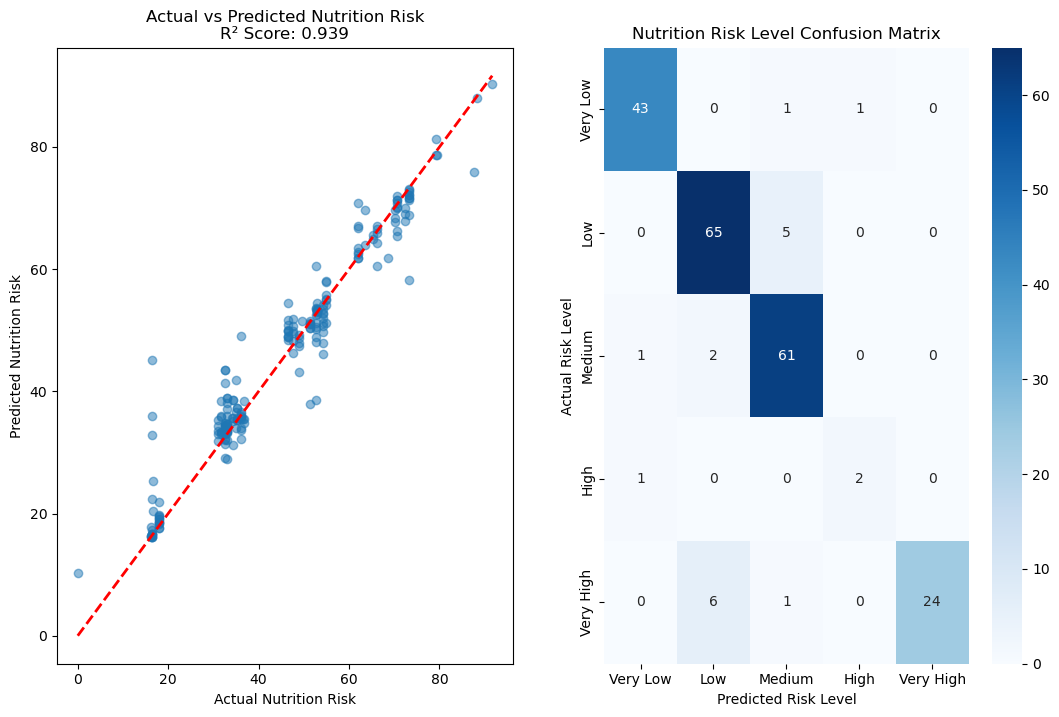

In [17]:
# After your existing model training code, add:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Train Random Forest model with better parameters
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# Create figure with multiple subplots
plt.figure(figsize=(20, 8))

# 1. Scatter plot of Actual vs Predicted values
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Nutrition Risk')
plt.ylabel('Predicted Nutrition Risk')
plt.title('Actual vs Predicted Nutrition Risk\nR² Score: {:.3f}'.format(r2_score(y_test, y_pred)))

# 2. Create bins for confusion matrix-style visualization
# Define risk levels based on your data distribution
bins = [0, 20, 40, 60, 80, 100]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

y_test_binned = pd.cut(y_test, bins=bins, labels=labels, include_lowest=True)
y_pred_binned = pd.cut(y_pred, bins=bins, labels=labels, include_lowest=True)

# Calculate confusion matrix
cm = confusion_matrix(y_test_binned, y_pred_binned)

# Plot confusion matrix
plt.subplot(1, 3, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Nutrition Risk Level Confusion Matrix')
plt.xlabel('Predicted Risk Level')
plt.ylabel('Actual Risk Level')

# 3. Feature Importance Plot
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

plt.subplot(1, 3, 3)
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('Top 10 Most Important Features')
plt.xlabel('Feature Importance')

plt.tight_layout()
plt.show()

# Print detailed metrics
print("\nRandom Forest Regression Metrics:")
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.3f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

# Print classification report for binned predictions
from sklearn.metrics import classification_report
print("\nClassification Report for Risk Levels:")
print(classification_report(y_test_binned, y_pred_binned))

# Print prediction examples
print("\nSample Predictions (First 10):")
print("Actual Risk | Predicted Risk | Difference | Risk Level (Actual → Predicted)")
print("-" * 75)
for actual, pred, act_bin, pred_bin in zip(y_test[:10], y_pred[:10], y_test_binned[:10], y_pred_binned[:10]):
    print(f"{actual:10.2f} | {pred:13.2f} | {abs(actual - pred):10.2f} | {act_bin} → {pred_bin}")

# Calculate error distribution
errors = y_test - y_pred
print("\nError Distribution:")
print(f"Mean Error: {np.mean(errors):.3f}")
print(f"Error Std Dev: {np.std(errors):.3f}")
print(f"Error Range: [{np.min(errors):.3f}, {np.max(errors):.3f}]")

# Plot error distribution
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=30, edgecolor='black')
plt.title('Prediction Error Distribution')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.show()